## Homework 2

### Seona Magdum

### 1 (a)

In [48]:
import pandas as pd

data = pd.read_excel("../data/Folds5x2_pp.xlsx")

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 1 (b) i

In [49]:
data.shape

(9568, 5)

In [50]:
data.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

### The dataset has 9568 rows and 5 columns. The five columns are AT, V, AP, RH AND PE with a total of 9568 attributes.

### 1 (b) ii

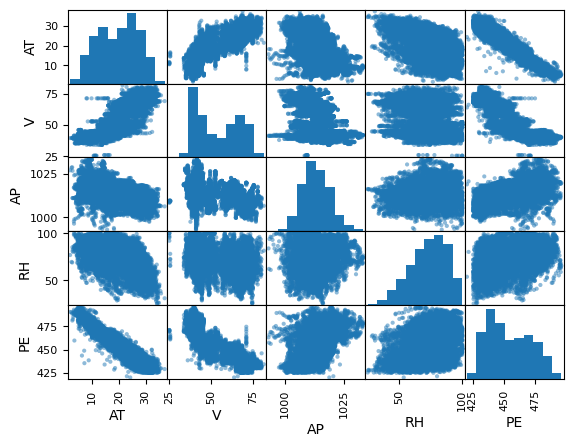

In [51]:
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(data)
plt.show()

### 1 (b) iii

In [52]:
summary = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### 1 (c)

In [53]:
import statsmodels.api as sm

In [54]:
#predictor AT
X = sm.add_constant(data["AT"])
y = data["PE"]
model_AT = sm.OLS(y, X).fit()
print(model_AT.summary())

#predictor V
X = sm.add_constant(data["V"])
model_V = sm.OLS(y, X).fit()
print(model_V.summary())

#predictor AP
X = sm.add_constant(data["AP"])
model_AP = sm.OLS(y, X).fit()
print(model_AP.summary())

#predictor RH
X = sm.add_constant(data["RH"])
model_RH = sm.OLS(y, X).fit()
print(model_RH.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

### All 4 predictors have a p value of 0.0 meaning each model is statistically significant. 

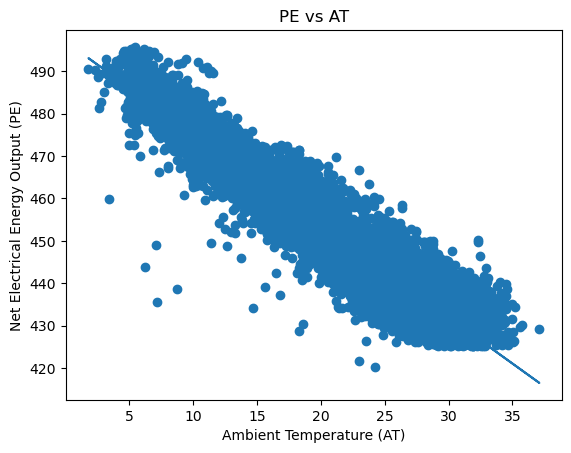

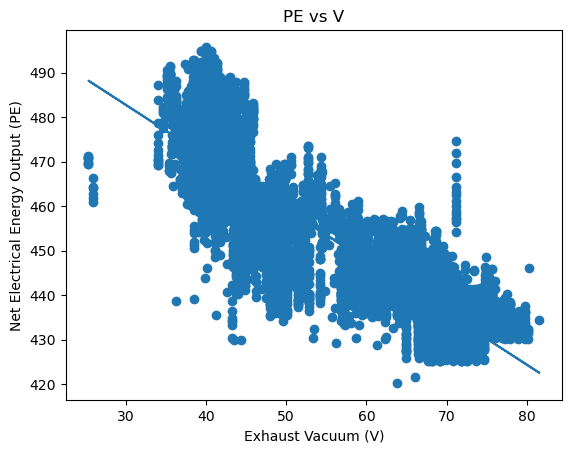

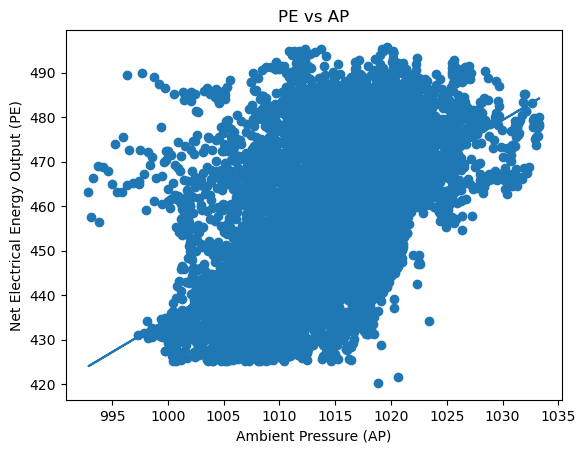

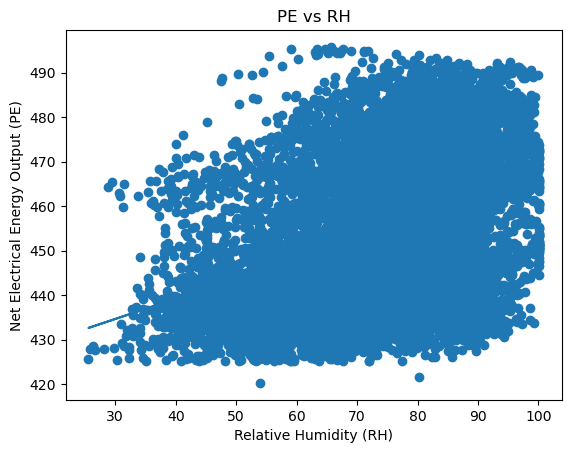

In [55]:
import matplotlib.pyplot as plt

#AT
plt.scatter(data["AT"], data["PE"])

plt.plot(data["AT"], model_AT.predict(sm.add_constant(data["AT"])))

plt.xlabel("Ambient Temperature (AT)")
plt.ylabel("Net Electrical Energy Output (PE)")
plt.title("PE vs AT")

plt.show()

#V
plt.scatter(data["V"], data["PE"])

plt.plot(data["V"], model_V.predict(sm.add_constant(data["V"])))

plt.xlabel("Exhaust Vacuum (V)")
plt.ylabel("Net Electrical Energy Output (PE)")
plt.title("PE vs V")

plt.show()

#AP
plt.scatter(data["AP"], data["PE"])

plt.plot(data["AP"], model_AP.predict(sm.add_constant(data["AP"])))

plt.xlabel("Ambient Pressure (AP)")
plt.ylabel("Net Electrical Energy Output (PE)")
plt.title("PE vs AP")

plt.show()

#RH
plt.scatter(data["RH"], data["PE"])

plt.plot(data["RH"], model_RH.predict(sm.add_constant(data["RH"])))

plt.xlabel("Relative Humidity (RH)")
plt.ylabel("Net Electrical Energy Output (PE)")
plt.title("PE vs RH")

plt.show()

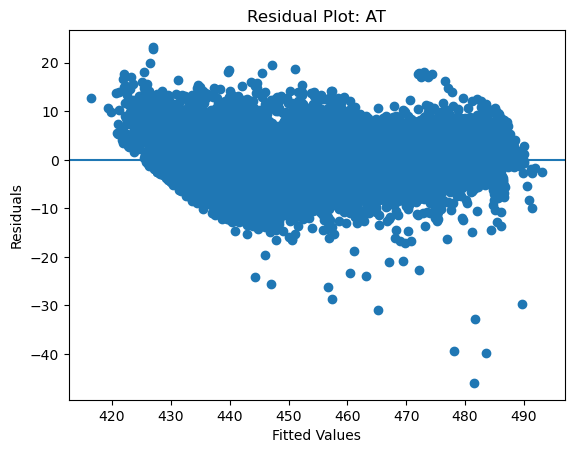

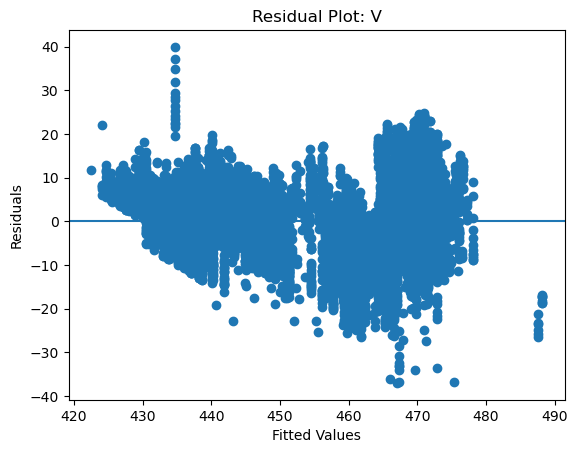

In [56]:
plt.scatter(model_AT.fittedvalues, model_AT.resid)

plt.axhline(0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot: AT")

plt.show()


plt.scatter(model_V.fittedvalues, model_V.resid)

plt.axhline(0)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot: V")

plt.show()

In [57]:
abs(model_AT.get_influence().resid_studentized_internal).max()

np.float64(8.470861424150259)

In [58]:
abs(model_V.get_influence().resid_studentized_internal).max()

np.float64(4.7453730395202145)

In [59]:
abs(model_AP.get_influence().resid_studentized_internal).max()

np.float64(4.130209397901521)

In [60]:
abs(model_RH.get_influence().resid_studentized_internal).max()

np.float64(3.022244638418247)

### When looking at the scatterplots for each predictor, I could see a negative correlation for PE vs AT and PE vs V. There are a few outliers for both of these plots. When checking the residual plot and the standardized residuls number the values are mostly approximately around 3-4, so I will not be removing the outliers. 

### 1 (d)

In [61]:
import statsmodels.api as sm

X = data[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)

y = data["PE"]

model_multiple = sm.OLS(y, X).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

### The multiple regression model was fit using all of the predictors to predict PE. The results show that all four predictors are statistically significant at the 0.05 significance level with a p value of 0.00. Therefore, we reject the null hypothesis for all the predictors AT, V, AP, and RH. All predictors have a statistically significant relationship with PE. 

### 1 (e) 

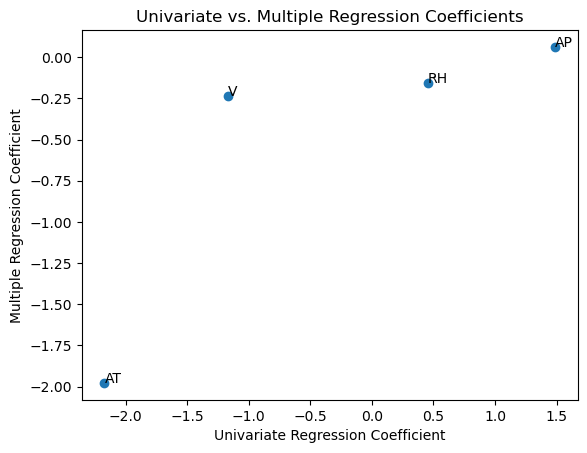

In [62]:
import matplotlib.pyplot as plt

#coefficients for simple
simple_coefficients = {
    "AT": model_AT.params["AT"],
    "V": model_V.params["V"],
    "AP": model_AP.params["AP"],
    "RH": model_RH.params["RH"]
}

#coefficients from multiple regression
multiple_coefficients = {
    "AT": model_multiple.params["AT"],
    "V": model_multiple.params["V"],
    "AP": model_multiple.params["AP"],
    "RH": model_multiple.params["RH"]
}

#plot
plt.scatter(
    simple_coefficients.values(),
    multiple_coefficients.values()
)

#label
for predictor in simple_coefficients:
    plt.annotate(
        predictor,
        (simple_coefficients[predictor],
         multiple_coefficients[predictor])
    )

plt.xlabel("Univariate Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Univariate vs. Multiple Regression Coefficients")
plt.show()

In [63]:
comparison = pd.DataFrame({
    "Univariate": simple_coefficients,
    "Multiple": multiple_coefficients
})

comparison

,Univariate,Multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


### As we can see in the plot as well as the dataframe, the coefficients for each predictor slighty vary based on the regression. for AT the number was about the same with both being around the value of -2. For predictor V we see a difference of around 0.9 when using different regressions. AP cahnged from a positive coefficient to being almost 0 and RH changes from negative to positive. Overall, V, AP, and RH showed much larger changes than AT after controlling for the other predictors.

### 1 (e)

In [64]:
import statsmodels.api as sm

#AT
X = data["AT"]
X_cubic = pd.DataFrame({
    "AT": X,
    "AT2": X**2,
    "AT3": X**3
})
X_cubic = sm.add_constant(X_cubic)
model_AT_cubic = sm.OLS(data["PE"], X_cubic).fit()
print(model_AT_cubic.summary())

#V
X = data["V"]
X_cubic = pd.DataFrame({
    "V": X,
    "V2": X**2,
    "V3": X**3
})
X_cubic = sm.add_constant(X_cubic)
model_V_cubic = sm.OLS(data["PE"], X_cubic).fit()
print(model_V_cubic.summary())

#AP
X = data["AP"]
X_cubic = pd.DataFrame({
    "AP": X,
    "AP2": X**2,
    "AP3": X**3
})
X_cubic = sm.add_constant(X_cubic)
model_AP_cubic = sm.OLS(data["PE"], X_cubic).fit()
print(model_AP_cubic.summary())

#RH
X = data["RH"]
X_cubic = pd.DataFrame({
    "RH": X,
    "RH2": X**2,
    "RH3": X**3
})
X_cubic = sm.add_constant(X_cubic)
model_RH_cubic = sm.OLS(data["PE"], X_cubic).fit()
print(model_RH_cubic.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

### There is evidence of nonlinear association between the predictors and PE using the cubic regression model. The higher-order terms were statistically significant for AT, AP, and RH with a p < 0.001. For predictor V, the cubic term was statistically significant, with p = 0.014 even though the quadratic term was not significant with p = 0.768. There is still evidence of a nonlinear association between PE and each of the four predictors.


### 1 (g)

In [65]:
X = data[["AT", "V", "AP", "RH"]].copy()

X["AT_V"] = data["AT"] * data["V"]
X["AT_AP"] = data["AT"] * data["AP"]
X["AT_RH"] = data["AT"] * data["RH"]
X["V_AP"] = data["V"] * data["AP"]
X["V_RH"] = data["V"] * data["RH"]
X["AP_RH"] = data["AP"] * data["RH"]

X = sm.add_constant(X)

y = data["PE"]

model_interactions = sm.OLS(y, X).fit()

print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

### A full linear regression model was fit with all four predictors and all of the interaction terms. There is evidence of a statistical significant interaction effects. The interaction terms AT*V, AT*RH, V*AP, and AP*RH were statistically significant with a p < 0.05. However, AT*AP (p = 0.452) and V* RH (p = 0.086) were not statistically significant.

### 1 (h) 

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

train, test = train_test_split(data, test_size=0.30, random_state=42)

print(train.shape)
print(test.shape)

(6697, 5)
(2871, 5)


In [67]:
#regular
X_train = train[["AT", "V", "AP", "RH"]]
X_test = test[["AT", "V", "AP", "RH"]]

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

y_train = train["PE"]
y_test = test["PE"]

model1 = sm.OLS(y_train, X_train).fit()

print(model1.summary())

train_predictions1 = model1.predict(X_train)
test_predictions1 = model1.predict(X_test)

train_mse1 = mean_squared_error(y_train, train_predictions1)
test_mse1 = mean_squared_error(y_test, test_predictions1)

print("Model 1 Train MSE:", train_mse1)
print("Model 1 Test MSE:", test_mse1)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        467.8414     11.502     40.673      0.0

In [68]:
#model 2 
X_train2 = train[["AT", "V", "AP", "RH"]].copy()
X_test2 = test[["AT", "V", "AP", "RH"]].copy()

# Quadratic terms
X_train2["AT2"] = train["AT"] ** 2
X_train2["V2"] = train["V"] ** 2
X_train2["AP2"] = train["AP"] ** 2
X_train2["RH2"] = train["RH"] ** 2

X_test2["AT2"] = test["AT"] ** 2
X_test2["V2"] = test["V"] ** 2
X_test2["AP2"] = test["AP"] ** 2
X_test2["RH2"] = test["RH"] ** 2

# Interaction terms
X_train2["AT_V"] = train["AT"] * train["V"]
X_train2["AT_AP"] = train["AT"] * train["AP"]
X_train2["AT_RH"] = train["AT"] * train["RH"]
X_train2["V_AP"] = train["V"] * train["AP"]
X_train2["V_RH"] = train["V"] * train["RH"]
X_train2["AP_RH"] = train["AP"] * train["RH"]

X_test2["AT_V"] = test["AT"] * test["V"]
X_test2["AT_AP"] = test["AT"] * test["AP"]
X_test2["AT_RH"] = test["AT"] * test["RH"]
X_test2["V_AP"] = test["V"] * test["AP"]
X_test2["V_RH"] = test["V"] * test["RH"]
X_test2["AP_RH"] = test["AP"] * test["RH"]

X_train2 = sm.add_constant(X_train2)
X_test2 = sm.add_constant(X_test2)

model2_full = sm.OLS(y_train, X_train2).fit()

print(model2_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:10   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

In [69]:
#emoved val with p > 0.05
X_train2_reduced = train[["AT", "V", "AP", "RH"]].copy()
X_test2_reduced = test[["AT", "V", "AP", "RH"]].copy()

# Quadratic terms
X_train2_reduced["AT2"] = train["AT"] ** 2
X_train2_reduced["AP2"] = train["AP"] ** 2
X_train2_reduced["RH2"] = train["RH"] ** 2

X_test2_reduced["AT2"] = test["AT"] ** 2
X_test2_reduced["AP2"] = test["AP"] ** 2
X_test2_reduced["RH2"] = test["RH"] ** 2

# Significant interactions
X_train2_reduced["AT_V"] = train["AT"] * train["V"]
X_train2_reduced["AT_RH"] = train["AT"] * train["RH"]
X_train2_reduced["AP_RH"] = train["AP"] * train["RH"]

X_test2_reduced["AT_V"] = test["AT"] * test["V"]
X_test2_reduced["AT_RH"] = test["AT"] * test["RH"]
X_test2_reduced["AP_RH"] = test["AP"] * test["RH"]

X_train2_reduced = sm.add_constant(X_train2_reduced)
X_test2_reduced = sm.add_constant(X_test2_reduced)


model2 = sm.OLS(y_train, X_train2_reduced).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:08:11   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.046e+04   1091.512     -9.581      0.0

In [70]:
train_predictions2 = model2.predict(X_train2_reduced)
test_predictions2 = model2.predict(X_test2_reduced)

train_mse2 = mean_squared_error(y_train, train_predictions2)
test_mse2 = mean_squared_error(y_test, test_predictions2)

print("Model 2 Train MSE:", train_mse2)
print("Model 2 Test MSE:", test_mse2)

Model 2 Train MSE: 17.91781267118588
Model 2 Test MSE: 18.694346190805785


### I first divided the data into a 70% training set with 6,697 observations and a 30% test set with 2,871 observations. I then fit a multiple linear regression model using all four predictors, which gave a training MSE of 20.581 and a test MSE of 21.240. I then fit a model with all predictors, quadratic terms, and interaction terms. After examining the p values, insignificant terms were removed. The final model included AT, V, AP, RH, AT^2 , AP^2 , RH^2, AT*V, AT*RH, and AP*RH. The improved model had a training MSE of 17.918 and a test MSE of 18.694. 

### 1 (i)

In [71]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [72]:
features = ["AT", "V", "AP", "RH"]

X_train = train[features]
X_test = test[features]

y_train = train["PE"]
y_test = test["PE"]

train_mse_raw = []
test_mse_raw = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    train_mse_raw.append(mean_squared_error(y_train, train_pred))
    test_mse_raw.append(mean_squared_error(y_test, test_pred))

best_k_raw = test_mse_raw.index(min(test_mse_raw)) + 1

print("Best k for raw features:", best_k_raw)
print("Train MSE:", train_mse_raw[best_k_raw - 1])
print("Test MSE:", test_mse_raw[best_k_raw - 1])

Best k for raw features: 5
Train MSE: 10.600768887561596
Test MSE: 15.726819842563568


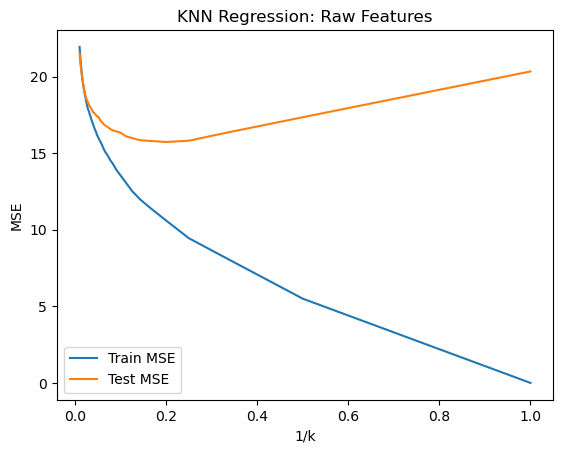

In [73]:
k_values = range(1, 101)
inverse_k = [1/k for k in k_values]

plt.plot(inverse_k, train_mse_raw, label="Train MSE")
plt.plot(inverse_k, test_mse_raw, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression: Raw Features")
plt.legend()
plt.show()

Best k for normalized features: 4
Train MSE: 8.591432839331045
Test MSE: 14.305669422675024


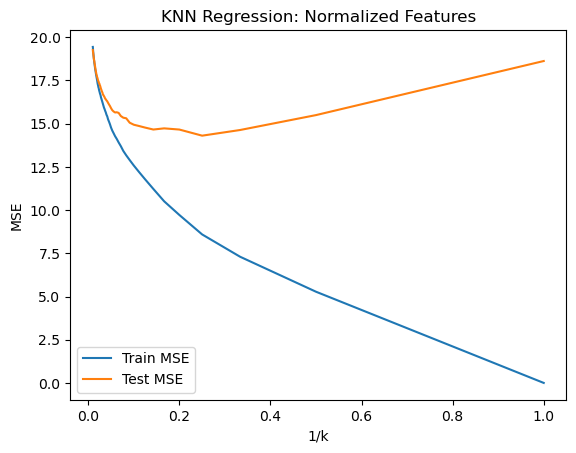

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_mse_scaled = []
test_mse_scaled = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_mse_scaled.append(mean_squared_error(y_train, train_pred))
    test_mse_scaled.append(mean_squared_error(y_test, test_pred))

best_k_scaled = test_mse_scaled.index(min(test_mse_scaled)) + 1

print("Best k for normalized features:", best_k_scaled)
print("Train MSE:", train_mse_scaled[best_k_scaled - 1])
print("Test MSE:", test_mse_scaled[best_k_scaled - 1])

plt.plot(inverse_k, train_mse_scaled, label="Train MSE")
plt.plot(inverse_k, test_mse_scaled, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression: Normalized Features")
plt.legend()
plt.show()

### (j)

### For KNN regression using the raw features the best value of k was 5, resulting in a training MSE of 10.601 and a test MSE of 15.727. When the predictors were normalized, the best value of k was 4, with a training MSE of 8.591 and a test MSE of 14.306. The linear regression model with quadratic and interaction terms had a test MSE of 18.694. Therefore, the normalized KNN model had a lower test MSE than the linear regression model. Normalizing the predictors also improved the KNN test MSE from 15.727 to 14.306 Overall, the normalized KNN model provided lower test prediction error than the linear regression models above.


### 2.4.1 

### a) If sample size n is extremely large, and the number of predictors p is small the flexible method would be better. An inflexible method may not be able to capture the complexity of the relationship between the predictors and the data. Since there is a large dataset, a flexible method can model more complex patterns without being as likely to overfit.
### b) If The number of predictors p is extremely large, and the number of observations n is small the inflexable method would be better since a flexible method is more likely to overfit the training data.
### c) If the relationship between the predictors and response is highly non-linear a flexible method could capture complex relationships between the predictors and response. An inflexible method may redult in a higher bias.
### d) If the variance of the error terms are really high an inflexable method would be better. Since the variance is high there is already a lot of random noise in the response. A flexible method may try to fit some of that extra data, leading to overfitting. An inflexible method is less likely to fit the random variation.

### 2.4.7 

### a)

In [75]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

data["Distance"] = np.sqrt(
    data["X1"]**2 +
    data["X2"]**2 +
    data["X3"]**2
)

data

,X1,X2,X3,Y,Distance
0,0,3,0,Red,3.000000
1,2,0,0,Red,2.000000
2,0,1,3,Red,3.162278
3,0,1,2,Green,2.236068
4,-1,0,1,Green,1.414214
5,1,1,1,Red,1.732051


### the closest observation is obs 5 with a value of 1.4

### b) Our prediction with K = 1 would be green because observation 5 is the closest.
### c) Our prediction with K = 3 would be red because the three nearest observations contain 2 red and 1 green.
### d) If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for K to be small, because a small K produces a more flexible model that can better capture a complex relationship between the predictors and the classes